<a href="https://colab.research.google.com/github/tojotk/IMDb_Movie_Reviews/blob/Model-Building/IMDb_Movie_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.4 MB/s eta 0:00:00


# Libraries

In [64]:
# Data manipulation and numerical computations
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing utilities
import re
import string
import nltk

# Natural Language Processing (NLP) resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

# Specific NLP preprocessing modules
from nltk.tokenize import word_tokenize # For splitting text into words
from nltk.corpus import stopwords       # For filtering common words
from nltk.stem import PorterStemmer     # For reducing words to their root form
from nltk.stem import WordNetLemmatizer # For reducing words to their base form (lemma)

# Scikit-learn for machine learning utilities
from sklearn.preprocessing import LabelEncoder # To convert categorical labels to numerical
from sklearn.model_selection import train_test_split # To split dataset for training and testing
from sklearn.feature_extraction.text import TfidfVectorizer # To convert text to numerical features

# Model evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Machine Learning model algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Gensim for Word2Vec embeddings
from gensim.models import Word2Vec

# TensorFlow/Keras for deep learning models
from tensorflow.keras.preprocessing.text import Tokenizer          # For text tokenization
from tensorflow.keras.preprocessing.sequence import pad_sequences  # For sequence padding

# Keras layers for building the neural network
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Concatenate

# Keras Model API for defining custom models
from tensorflow.keras.models import Model

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Read dataset

In [6]:
df_movie = pd.read_csv('/content/drive/MyDrive/AI ML Course/Data/IMDB Dataset.csv')
df_movie.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# EDA

In [7]:
df_movie.shape

(50000, 2)

In [8]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
df_movie.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [10]:
df_movie.isnull().sum()

,0
review,0
sentiment,0


In [11]:
# view sentiment distrubution
df_movie["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Plot Visualization

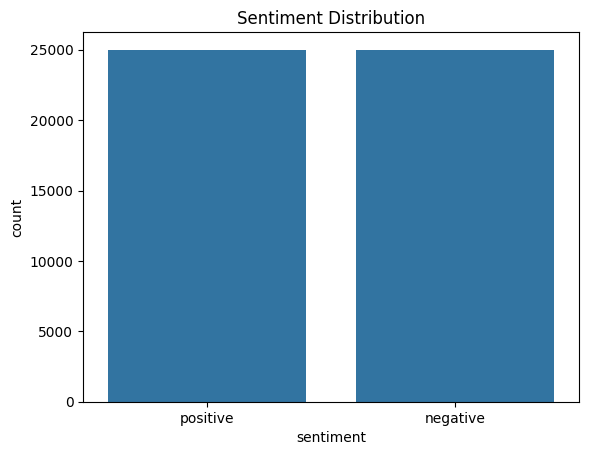

In [12]:
# Draw bar chart
sns.countplot(x="sentiment", data=df_movie)
plt.title("Sentiment Distribution")
plt.show()

In [13]:
# Checking review length

In [14]:
# Count number of words in each review
df_movie["Review_Length"] = df_movie["review"].apply(lambda x: len(x.split()))
df_movie["Review_Length"].head()

,Review_Length
0,307
1,162
2,166
3,138
4,230


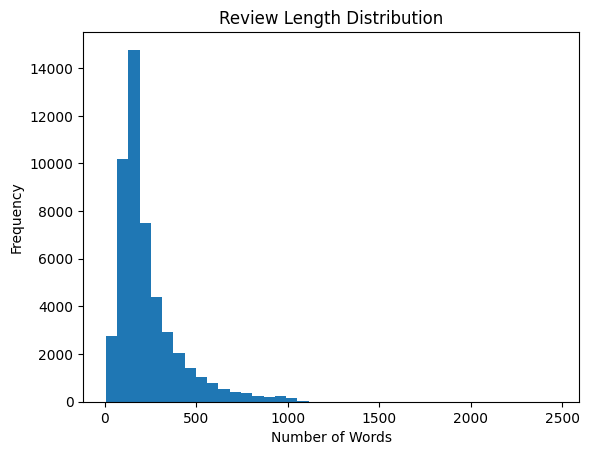

In [15]:
# Plot histogram
plt.hist(df_movie["Review_Length"], bins=40)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")

plt.show()

# Text Preprocessing

## Duplicates removal

In [16]:
df_movie.duplicated().sum()

np.int64(418)

In [17]:
df_movie.drop_duplicates(inplace=True)

In [18]:
df_movie.duplicated().sum()

np.int64(0)

## Missing value

In [19]:
df_movie.isnull().sum()

,0
review,0
sentiment,0
Review_Length,0


## Remove html tags

In [20]:
# Function to remove HTML tags
def remove_html(text):
    clean = re.compile("<.*?>")
    return re.sub(clean, "", text)
df_movie["review"] = df_movie["review"].apply(remove_html)

## Convert to lowercase

In [21]:
# Convert all text into lowercase
df_movie["review"] = df_movie["review"].str.lower()

## Remove Punctuations

In [22]:
# Function to remove punctuation
def remove_punctuation(text):
    # Remove punctuation characters
    return text.translate(str.maketrans("", "", string.punctuation))
df_movie["review"] = df_movie["review"].apply(remove_punctuation)

## Tokenization

In [23]:
# Convert sentence into list of words
df_movie["Tokens"] = df_movie["review"].apply(word_tokenize)
# Display first review tokens
df_movie["Tokens"].head()

,Tokens
0,"[one, of, the, other, reviewers, has, mentione..."
1,"[a, wonderful, little, production, the, filmin..."
2,"[i, thought, this, was, a, wonderful, way, to,..."
3,"[basically, theres, a, family, where, a, littl..."
4,"[petter, matteis, love, in, the, time, of, mon..."


## Remove Stopwords

In [24]:
# Load  stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords
df_movie["Tokens"] = df_movie["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

## Stemming

In [25]:
# Create stemmer object
stemmer = PorterStemmer()

# Apply stemming
df_movie["Stemmed"] = df_movie["Tokens"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

## Lemmatization

In [26]:
# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df_movie["Lemmatized"] = df_movie["Tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

## Convert tokens back to sentence

In [27]:
# Join words into a sentence
df_movie["Clean_Review"] = df_movie["Lemmatized"].apply(lambda words: " ".join(words))

# Display cleaned reviews
df_movie[["review", "Clean_Review"]].head()

,review,Clean_Review
0,one of the other reviewers has mentioned that ...,one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...


In [28]:
df_movie.head()

,review,sentiment,Review_Length,Tokens,Stemmed,Lemmatized,Clean_Review
0,one of the other reviewers has mentioned that ...,positive,307,"[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, y...","[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,positive,162,"[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,positive,166,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,negative,138,"[basically, theres, family, little, boy, jake,...","[basic, there, famili, littl, boy, jake, think...","[basically, there, family, little, boy, jake, ...",basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,positive,230,"[petter, matteis, love, time, money, visually,...","[petter, mattei, love, time, money, visual, st...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...


Esha

## Split Features and Target

In [31]:
# Define the input feature (cleaned review text)
# and the target variable (sentiment).

X = df_movie["Clean_Review"]

y = df_movie["sentiment"]

## Train-Test Split

In [32]:
# Split the dataset into training and testing sets.
# Stratify ensures both sets maintain the same proportion of positive and negative reviews.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Display the size of the training and testing datasets.
print(X_train.shape)
print(X_test.shape)

(39665,)
(9917,)


## Encode the Target Variable

In [29]:
# Convert the target labels ('positive' and 'negative')
# into numerical values (1 and 0) for machine learning models.
label_enc = LabelEncoder()

df_movie["sentiment"] = label_enc.fit_transform(df_movie["sentiment"])
# Display the number of positive and negative reviews.
df_movie["sentiment"].value_counts()

,count
sentiment,
1,24884
0,24698


In [30]:
df_movie.head(3)

,review,sentiment,Review_Length,Tokens,Stemmed,Lemmatized,Clean_Review
0,one of the other reviewers has mentioned that ...,1,307,"[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, y...","[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,1,162,"[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,1,166,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...


# Feature Engineering

## Convert Text into Numbers using TF-IDF

In [33]:
# Convert the cleaned text into numerical feature vectors
# using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.
tfidf = TfidfVectorizer(
    max_features=10000,    #Keep only the top 10,000 important words.
    ngram_range=(1,2)      #Use both single words and pairs of words.

)
# Learn the vocabulary from the training data and transform the text into TF-IDF vectors.
X_train_tfidf = tfidf.fit_transform(X_train)
# Transform the test data using the same vocabulary.
X_test_tfidf = tfidf.transform(X_test)

In [34]:
# Display the dimensions of the TF-IDF matrices.
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(39665, 10000)
(9917, 10000)


## Train Logistic Regression

In [35]:
# Create a Logistic Regression classifier
# and train it using the TF-IDF feature vectors.
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)
# Predict the sentiment labels for the unseen test dataset.
y_pred_lr = model.predict(X_test_tfidf)

# Calculate the overall accuracy of the trained model.
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", accuracy_lr)

Accuracy : 0.8916002823434507


##Compare Multiple Models

In [63]:
## Compare Multiple Models

## Classification Report for Logistic Regression

In [37]:
# Display Precision, Recall, F1-score, and Support for each sentiment class.

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



## Confusion Matrix for Logistic Regression

In [38]:
# Generate the confusion matrix to compare actual labels with predicted labels.

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[4348  592]
 [ 483 4494]]


### Plot Confusion Matrix

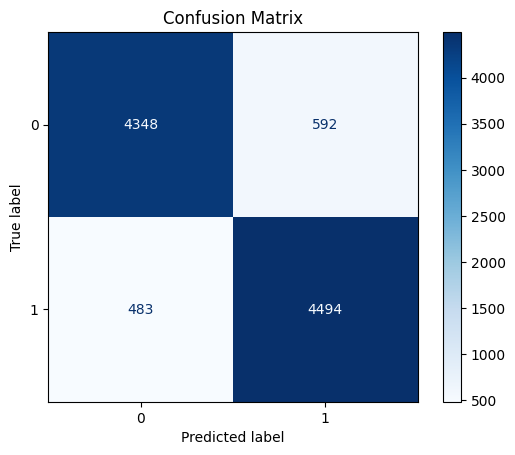

In [39]:
# Display the confusion matrix using a heatmap-style visualization.

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

## Predict on a New Review

In [40]:
# Predict the sentiment of a new movie review  entered by the user.

review = ["This movie was absolutely fantastic. I loved every scene."]

review = tfidf.transform(review)

prediction = model.predict(review)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


In [41]:
# Test the model using another example review.

review1 = ["Worst movie ever. Waste of time."]

review1 = tfidf.transform(review1)

prediction = model.predict(review1)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review


## Word2vec Model

## Tokenize Reviews

In [43]:
X_train_tokens = [review.split() for review in X_train]
X_test_tokens = [review.split() for review in X_test]

## Train Word2Vec Model

In [65]:
# Initialize and train the Word2Vec model.
# sentences: The tokenized sentences (list of lists of words) from the training data.
# vector_size: The dimensionality of the word embeddings (100 in this case).
# window: The maximum distance between the current and predicted word within a sentence.
# min_count: Ignores all words with a total frequency lower than this. Ensures robust embeddings.
# workers: Number of CPU cores to use for training the model.
# sg: Training algorithm; 1 for skip-gram, 0 for CBOW. Skip-gram is often better for rare words.
word2vec_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

# Print the total number of unique words that have learned embeddings in the model's vocabulary.
print("Vocabulary Size:", len(word2vec_model.wv))

Vocabulary Size: 65979


## Create Average Word Vectors

In [66]:
def document_vector(tokens, model):
    """
    Generates a document vector (embedding) by averaging the word vectors of its tokens.

    Args:
        tokens (list): A list of words (tokens) representing a document.
        model (gensim.models.Word2Vec): The trained Word2Vec model.

    Returns:
        numpy.ndarray: A numerical vector representing the document. If no words in the document
                       are found in the Word2Vec model's vocabulary, a zero vector is returned.
    """
    # Collect word vectors for all tokens present in the Word2Vec model's vocabulary.
    vectors = []
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    # If no word vectors were found (i.e., document contains only out-of-vocabulary words),
    # return a zero vector of the correct dimensionality.
    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    # Otherwise, compute the mean of all collected word vectors to get the document vector.
    return np.mean(vectors, axis=0)

## Convert Reviews to Vectors

In [48]:
X_train_w2v = np.array([
    document_vector(tokens, word2vec_model)
    for tokens in X_train_tokens
])

X_test_w2v = np.array([
    document_vector(tokens, word2vec_model)
    for tokens in X_test_tokens
])

print(X_train_w2v.shape)

(39665, 100)


## Train Logistic Regression

In [49]:
lr_w2v = LogisticRegression(max_iter=1000)

lr_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = lr_w2v.predict(X_test_w2v)

print("Accuracy :", accuracy_score(y_test, y_pred_w2v))

print("\nClassification Report\n")

print(classification_report(y_test, y_pred_w2v))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, y_pred_w2v))

Accuracy : 0.8728446102652012

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4940
           1       0.87      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917


Confusion Matrix

[[4284  656]
 [ 605 4372]]


# Deep Learning Model (Functional API)

## Tokenizer

In [62]:
# Define the maximum number of unique words to keep in the vocabulary.
max_words = 20000

# Initialize the Tokenizer with the specified maximum number of words.
# Words will be ranked by frequency, and only the most frequent will be kept.
tokenizer = Tokenizer(num_words=max_words)

# Fit the Tokenizer on the training text data (X_train).
# This builds the vocabulary based on the words present in X_train.
tokenizer.fit_on_texts(X_train)

## Convert Reviews into Sequences

In [51]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

##Padding

In [52]:
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

## Functional API Model (Multiple Embedding Inputs)

In [67]:
# Determine the vocabulary size for the embedding layer. It's the minimum of 'max_words'
# and the actual number of unique words in the tokenizer's vocabulary plus one (for padding/OOD).
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

# Define the input layer with a fixed sequence length.
inputs = Input(shape=(max_length,))

# First Embedding layer: Maps integer-encoded words to dense vectors (128 dimensions).
# input_dim: Size of the vocabulary.
# output_dim: Dimension of the dense embedding. Represents each word with 128 features.
# input_length: Length of input sequences. Used for internal shape inference (though deprecated).
embedding1 = Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_length
)(inputs)

# Second Embedding layer: Another embedding layer with different output dimensions (64 dimensions).
# This allows the model to learn different representations for the same input words,
# potentially capturing different aspects of meaning or context.
embedding2 = Embedding(
    input_dim=vocab_size,
    output_dim=64,
    input_length=max_length
)(inputs)

# GlobalAveragePooling1D for the first embedding output.
# This layer averages the embeddings across the time dimension (words in a sequence),
# converting each sequence into a single fixed-size vector.
pool1 = GlobalAveragePooling1D()(embedding1)

# GlobalAveragePooling1D for the second embedding output.
pool2 = GlobalAveragePooling1D()(embedding2)

# Concatenate the outputs of the two pooling layers.
# This merges the two different representations into a single, richer feature vector.
merged = Concatenate()([pool1, pool2])

# First Dense (fully connected) layer with 128 units and ReLU activation.
# ReLU (Rectified Linear Unit) is a common activation function for hidden layers.
dense1 = Dense(128, activation='relu')(merged)

# Second Dense layer with 64 units and ReLU activation.
dense2 = Dense(64, activation='relu')(dense1)

# Output Dense layer with 1 unit and Sigmoid activation.
# Sigmoid activation is used for binary classification, outputting a probability between 0 and 1.
output = Dense(1, activation='sigmoid')(dense2)

# Create the functional model, defining its inputs and outputs.
functional_model = Model(
    inputs=inputs,
    outputs=output
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [54]:
functional_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 64)   │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ embedding[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ embedding_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,873,025 (14.77 MB)

 Trainable params: 3,873,025 (14.77 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# Compile the functional API model.
# optimizer: The algorithm used to update model weights during training (Adam is a popular choice).
# loss: The loss function to minimize (binary_crossentropy for binary classification).
# metrics: Additional metrics to monitor during training and evaluation (accuracy in this case).
functional_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##Train

In [69]:
# Train the deep learning model.
# X_train_pad: The padded sequence data for training.
# y_train: The corresponding target labels for training.
# validation_split: Fraction of the training data to be used as validation data (0.2 means 20%).
# epochs: Number of times to iterate over the entire training dataset.
# batch_size: Number of samples per gradient update. Training data is split into batches.
# verbose: Controls the verbosity of the output during training (1 shows progress bar).
history = functional_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.7813 - loss: 0.4382 - val_accuracy: 0.8409 - val_loss: 0.3450
Epoch 2/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.8975 - loss: 0.2518 - val_accuracy: 0.8819 - val_loss: 0.2875
Epoch 3/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9207 - loss: 0.2017 - val_accuracy: 0.8426 - val_loss: 0.4054
Epoch 4/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9323 - loss: 0.1761 - val_accuracy: 0.8262 - val_loss: 0.4563
Epoch 5/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.9459 - loss: 0.1427 - val_accuracy: 0.8830 - val_loss: 0.3230


##Evaluate

In [70]:
# Evaluate the trained deep learning model on the test dataset.
# It returns the loss value and metric values (e.g., accuracy) for the model.
loss, accuracy = functional_model.evaluate(
    X_test_pad,
    y_test
)

# Print the test accuracy.
print("Test Accuracy :", accuracy)

# Predict probabilities for the test dataset.
# The output will be a 2D array where each element is the probability of the positive class.
y_pred_prob = functional_model.predict(X_test_pad)

# Convert predicted probabilities into binary class labels (0 or 1).
# If probability > 0.5, classify as 1 (positive); otherwise, classify as 0 (negative).
y_pred_dl = (y_pred_prob > 0.5).astype(int)

310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8823 - loss: 0.3149
Test Accuracy : 0.8823232650756836
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


##Classification Report

In [58]:
print(classification_report(y_test, y_pred_dl))

print(confusion_matrix(y_test, y_pred_dl))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88      4940
           1       0.86      0.92      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917

[[4212  728]
 [ 394 4583]]


## Plot Accuracy

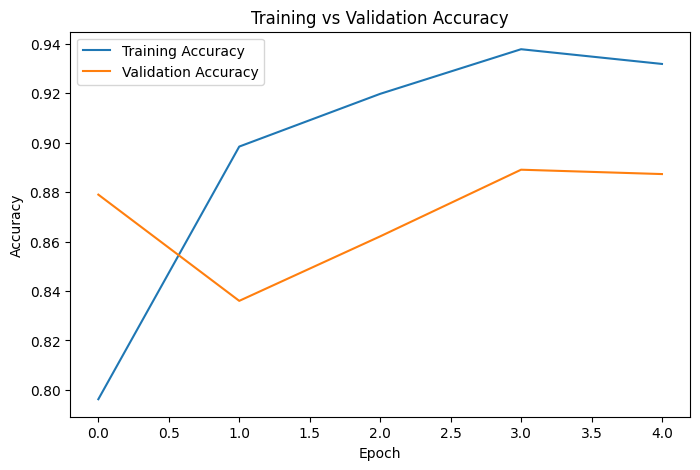

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

## Plot Loss

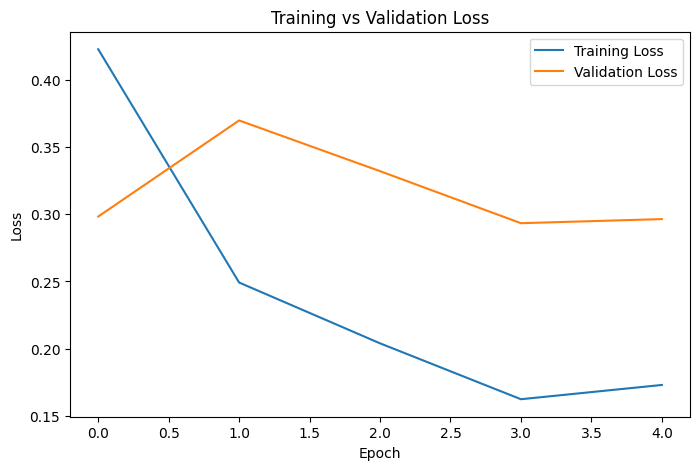

In [60]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

##Compare All Models

In [61]:
results = {
    "TF-IDF + Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Word2Vec + Logistic Regression": accuracy_score(y_test, y_pred_w2v),
    "Functional API Deep Learning": accuracy
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

TF-IDF + Logistic Regression: 0.8916
Word2Vec + Logistic Regression: 0.8728
Functional API Deep Learning: 0.8869
